# M4A5 - Fundamentos de Modelos Multimodais

Na prática de hoje vamos usar o modelo [CLIP](https://openai.com/index/clip/) da OpenAI.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Utilizar o modelo
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install git+https://github.com/openai/CLIP.git

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/openai/CLIP.git to /private/var/folders/rh/2nww50x55q751dst7bhwgj7r0000gn/T/pip-req-build-jb36dkv_
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /private/var/folders/rh/2nww50x55q751dst7bhwgj7r0000gn/T/pip-req-build-jb36dkv_
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369549 sha256=b8f9fab6208d9b3e08239917abfe45460f33f3ca304cc7809c6b4176bd9f79f9
  Stored in directory: /private/var/folders/rh/2nww50x55q751dst7bhwgj7r0000gn/T/pip-ephem-wheel-cache-zc00ladl/wheels/c8/e4/e1/11374c111387672fc2068dfbe0d4b424cb9cdd1b2e184a71b5
Successfully built clip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import torch
import clip
import matplotlib.pyplot as plt
from PIL import Image

## Utilizar o Modelo

Para isso iremos instanciar o modelo do CLIP e utilizar com texto e imagens.

['a statue', 'the moutains', 'the beach']
Probabilidades imagem vs. textos: [96.19% de "a statue", 3.80% de "the moutains", 0.01% de "the beach"]


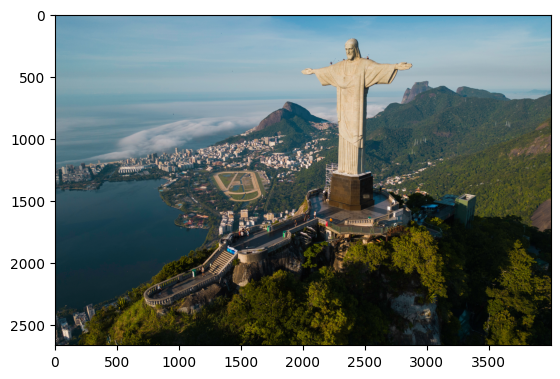

In [4]:
# Path para a imagem.
path_image = "../assets/modulo4/rio.jpeg"
# path_image = "images/dog.jpeg"

# Textos para avaliar.
texts = ["a statue", "the moutains", "the beach"]
# texts = ["a cat", "a dog", "a diagram"]

# Define o dispositivo a carregar o modelo.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Carrega o modelo com o backbone do ViT-B/32.
model, preprocess = clip.load("ViT-B/32", device=device)


# Processa a imagem.
image = preprocess(Image.open(path_image)).unsqueeze(0).to(device)

# Processa o texto.
text = clip.tokenize(texts).to(device)

# Roda inferências.
with torch.no_grad():
    _ = model.encode_image(image) # Encoda imagem.
    _ = model.encode_text(text) # Encoda o texto.
    
    logits_per_image, logits_per_text = model(image, text) # Computa similaridade entre imagem e textos.
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0] # Retorna probabilidades.

formated_probs_str = '[' + ', '.join(f'{x * 100:.2f}% de "{t}"' for x, t in zip(list(probs), texts)) + ']'

plt.imshow(Image.open(path_image))
print(texts)
print("Probabilidades imagem vs. textos:", formated_probs_str)

## Próximos Passos e Referências

Nas próximas práticas vamos trabalhar com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://github.com/openai/CLIP
- https://openai.com/index/clip/
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [x] Tente utilizar outros dados imagens e textos.
- [x] Tente utilizar outro modelo base do CLIP. Details on https://github.com/openai/CLIP/blob/main/model-card.md#model-versions .

### Atividade 1 — Outras imagens e textos

Trocando a imagem do Rio pela do cachorro e testando com descrições mais específicas pra ver como o modelo reage.

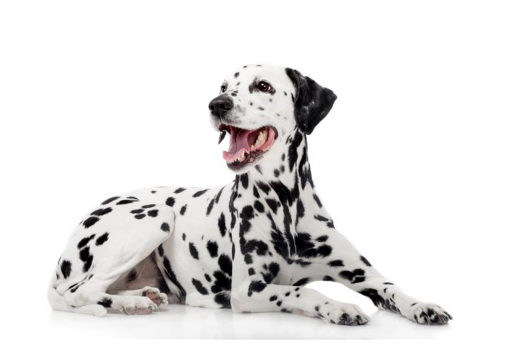

Textos: ['a dog sitting', 'a cat sleeping', 'a person walking', 'grass and trees']
Probabilidades: [99.93% de "a dog sitting", 0.01% de "a cat sleeping", 0.06% de "a person walking", 0.00% de "grass and trees"]


In [6]:
# Atividade 1: usando a imagem do cachorro com textos diferentes
path_image_ac1 = "../assets/modulo4/dog.jpeg"

# Textos mais específicos pra ver qual o modelo acha mais parecido
texts_ac1 = ['a dog sitting', 'a cat sleeping', 'a person walking', 'grass and trees']

image_ac1 = preprocess(Image.open(path_image_ac1)).unsqueeze(0).to(device)
text_ac1 = clip.tokenize(texts_ac1).to(device)

with torch.no_grad():
    logits_per_image, _ = model(image_ac1, text_ac1)
    probs_ac1 = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

formated_ac1 = '[' + ', '.join(f'{x * 100:.2f}% de "{t}"' for x, t in zip(probs_ac1, texts_ac1)) + ']'

plt.imshow(Image.open(path_image_ac1))
plt.axis('off')
plt.show()
print('Textos:', texts_ac1)
print('Probabilidades:', formated_ac1)


### Atividade 2 — Trocando o modelo base

O CLIP tem vários backbones disponíveis. Aqui vou usar o `RN50` (ResNet-50) que é mais leve que o `ViT-B/32`, pra comparar os resultados.

/Users/larry/Library/Python/3.9/lib/python/site-packages/clip/clip.py:57: UserWarning: /Users/larry/.cache/clip/RN50.pt exists, but the SHA256 checksum does not match; re-downloading the file
  warnings.warn(f"{download_target} exists, but the SHA256 checksum does not match; re-downloading the file")
100%|███████████████████████████████████████| 244M/244M [00:14<00:00, 17.3MiB/s]


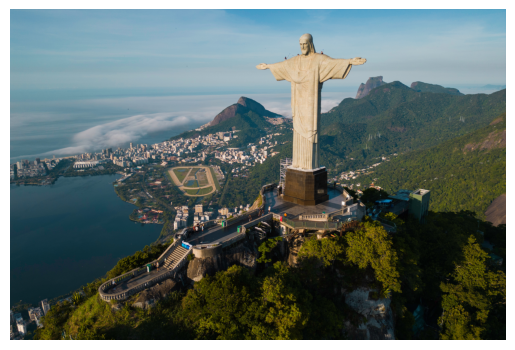

Modelo: RN50
Textos: ['a statue', 'the mountains', 'the beach']
Probabilidades: [96.00% de "a statue", 3.89% de "the mountains", 0.10% de "the beach"]

Comparação ViT-B/32 vs RN50 — mesma imagem, mesmos textos


In [ ]:
# Atividade 2: carrega um backbone diferente — RN50 em vez de ViT-B/32
model_rn50, preprocess_rn50 = clip.load('RN50', device=device)

# Mantém a mesma imagem e textos do exemplo original pra facilitar a comparação
path_image_ac2 = "../assets/modulo4/rio.jpeg"
texts_ac2 = ['a statue', 'the mountains', 'the beach']

image_ac2 = preprocess_rn50(Image.open(path_image_ac2)).unsqueeze(0).to(device)
text_ac2 = clip.tokenize(texts_ac2).to(device)

with torch.no_grad():
    logits_ac2, _ = model_rn50(image_ac2, text_ac2)
    probs_ac2 = logits_ac2.softmax(dim=-1).cpu().numpy()[0]

formated_ac2 = '[' + ', '.join(f'{x * 100:.2f}% de "{t}"' for x, t in zip(probs_ac2, texts_ac2)) + ']'

plt.imshow(Image.open(path_image_ac2))
plt.axis('off')
plt.show()
print('Modelo: RN50')
print('Textos:', texts_ac2)
print('Probabilidades:', formated_ac2)

# mostra o que muda de um modelo pro outro
print('\nComparação ViT-B/32 vs RN50 — mesma imagem, mesmos textos')
